In [11]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_excel(r'datos_tratados_7anomalias1_1_todos.xlsx', sheet_name = "Import")

## División de datasets

In [13]:
dataF = data
dataF = dataF.drop(columns=['tinygsSatellite'])
dataF.index = range(dataF.shape[0])

data1 = data[data['tinygsSatellite'] == 'CSTP-1.1']
data1 = data1.drop(columns=['tinygsSatellite'])
data1.index = range(data1.shape[0])

data2 = data[data['tinygsSatellite'] == 'CSTP-1.2']
data2 = data2.drop(columns=['tinygsSatellite'])
data2.index = range(data2.shape[0])

data3 = data[data['tinygsSatellite'] == 'Polytech_Universe-3']
data3 = data3.drop(columns=['tinygsSatellite'])
data3.index = range(data3.shape[0])

## Tratamiento de variables categóricas

In [14]:
# Tratamiento de variables categóricas mediante One-Hot encoder: tinygsSatellite, psuFlags, psuFlag2, bat1Flag, chargerFlag
oheF = OneHotEncoder(sparse_output=False)
ohe1 = OneHotEncoder(sparse_output=False)
ohe2 = OneHotEncoder(sparse_output=False)
ohe3 = OneHotEncoder(sparse_output=False)

# Aplicar One-Hot Encoding
df_oheF = oheF.fit_transform(dataF[['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']])
df_ohe1 = ohe1.fit_transform(data1[['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']])
df_ohe2 = ohe2.fit_transform(data2[['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']])
df_ohe3 = ohe3.fit_transform(data3[['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']])

# Convertir a DataFrame y asignar nombres de columnas
df_oheF = pd.DataFrame(df_oheF, columns=oheF.get_feature_names_out(['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']))
df_ohe1 = pd.DataFrame(df_ohe1, columns=ohe1.get_feature_names_out(['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']))
df_ohe2 = pd.DataFrame(df_ohe2, columns=ohe2.get_feature_names_out(['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']))
df_ohe3 = pd.DataFrame(df_ohe3, columns=ohe3.get_feature_names_out(['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag']))

# Concatenar con el DataFrame original
dataF = pd.concat([dataF, df_oheF], axis=1)
data1 = pd.concat([data1, df_ohe1], axis=1)
data2 = pd.concat([data2, df_ohe2], axis=1)
data3 = pd.concat([data3, df_ohe3], axis=1)

# Eliminamos las variables categóricas no tratadas
dataF = dataF.drop(columns=['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag'])
data1 = data1.drop(columns=['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag'])
data2 = data2.drop(columns=['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag'])
data3 = data3.drop(columns=['psuFlags', 'psuFlag2', 'bat1Flag', 'chargerFlag'])

In [15]:
print(dataF.shape)
print(data1.shape)
print(data2.shape)
print(data3.shape)

(10063, 54)
(2915, 50)
(3680, 37)
(3468, 52)


In [16]:
# Calculamos la desviación de las nuevas variables -> borrar bat1Flag_2
dataF.std()

satUptime              50030.441485
psuTemp                   16.119458
batCharge                 22.585730
tempBatMin                20.314386
tempBatMax                 8.680650
iPsuCh1                    3.622255
iPsuCh2                    3.740091
iPsuCh3                    3.245077
iPsuCh5                    3.906908
iPsuCh6                    2.712274
iPsuCh7                    4.190629
bat1I                    200.579134
bat1Cap                 3429.074969
bat2I                    216.680135
bat2Cap                 1265.785453
tinygsSolarVoltage2       21.185224
tinygsSolarVoltage3       11.155409
tinygsVbus              1109.212110
tinygsSolarCurrent1      107.077570
tinygsBatVoltage2       1164.414651
tinygsSolarCurrent2      130.567647
tinygsIbus              2510.277643
tinygsBatVoltage        1036.814742
tinygsSolarCurrent3       87.672451
tinygsSolarVoltage1       17.855157
anomaly                    0.326187
psuFlags_3843              0.500017
psuFlags_3845              0

In [17]:
# Calculamos la desviación de las nuevas variables -> borrar nada
data1.std()

satUptime              52813.789010
psuTemp                   24.696328
batCharge                 33.433164
tempBatMin                 6.252105
tempBatMax                 5.150121
iPsuCh1                    4.625048
iPsuCh2                    5.713963
iPsuCh3                    4.297392
iPsuCh5                    6.983950
iPsuCh6                    4.757078
iPsuCh7                    7.127608
bat1I                    341.254926
bat1Cap                 1244.625754
bat2I                    315.831516
bat2Cap                 1111.903549
tinygsSolarVoltage2       17.143985
tinygsSolarVoltage3       11.490162
tinygsVbus              1283.925449
tinygsSolarCurrent1      183.688116
tinygsBatVoltage2       1224.253562
tinygsSolarCurrent2      232.499309
tinygsIbus               573.981010
tinygsBatVoltage         633.728130
tinygsSolarCurrent3      106.107782
tinygsSolarVoltage1       20.279273
anomaly                    0.303901
psuFlags_3843              0.492823
psuFlags_3846              0

In [18]:
# Calculamos la desviación de las nuevas variables -> borrar psuFlag2_4, bat1Flag_50, iPsuCh1, iPsuCh2, iPsuCh5, iPsuCh6, iPsuCh7
data2.std()

satUptime              45037.561190
psuTemp                    9.730658
batCharge                 16.150873
tempBatMin                21.847184
tempBatMax                11.911516
iPsuCh1                    0.000000
iPsuCh2                    0.000000
iPsuCh3                    0.077098
iPsuCh5                    0.000000
iPsuCh6                    0.000000
iPsuCh7                    0.000000
bat1I                     39.316469
bat1Cap                 4248.489390
bat2I                    184.658890
bat2Cap                  938.600923
tinygsSolarVoltage2       27.774269
tinygsSolarVoltage3       11.857058
tinygsVbus               468.877425
tinygsSolarCurrent1       36.566300
tinygsBatVoltage2        672.315287
tinygsSolarCurrent2       36.336137
tinygsIbus              1989.869683
tinygsBatVoltage         603.596619
tinygsSolarCurrent3       35.656696
tinygsSolarVoltage1       16.527827
anomaly                    0.331072
psuFlags_3843              0.488765
psuFlags_3845              0

In [19]:
# Calculamos la desviación de las nuevas variables -> borrar nada
data3.std()

satUptime              51515.900118
psuTemp                   10.735944
batCharge                 16.234345
tempBatMin                25.638792
tempBatMax                 6.501777
iPsuCh1                    1.434353
iPsuCh2                    2.062836
iPsuCh3                    1.124998
iPsuCh5                    1.096756
iPsuCh6                    0.866358
iPsuCh7                    2.473919
bat1I                    130.686823
bat1Cap                 3435.293870
bat2I                    123.816268
bat2Cap                  908.380190
tinygsSolarVoltage2       15.332575
tinygsSolarVoltage3        9.960455
tinygsVbus               832.538696
tinygsSolarCurrent1       36.824314
tinygsBatVoltage2        912.067837
tinygsSolarCurrent2       35.588450
tinygsIbus              3715.690625
tinygsBatVoltage         982.706981
tinygsSolarCurrent3      103.670462
tinygsSolarVoltage1       17.020741
anomaly                    0.338296
psuFlags_3843              0.497663
psuFlags_3845              0

In [20]:
# Se descartan los campos que no aportan información
# dataF = dataF.drop(columns=['bat1Flag_2'])
data1 = data1.drop(columns=['bat1Flag_2'])
data2 = data2.drop(columns=['psuFlag2_4', 'bat1Flag_50', 'iPsuCh1', 'iPsuCh2', 'iPsuCh5', 'iPsuCh6', 'iPsuCh7'])
# data3 = data3.drop(columns=['bat1Flag_2'])

## Normalización

In [21]:
# Se formatea el tiempo y se elimina para normalización
sat_time_originalF = dataF['satUptime']
sat_timeF = sat_time_originalF - min(sat_time_originalF)
dataF = dataF.drop(columns=['satUptime'])

sat_time_original1 = data1['satUptime']
sat_time1 = sat_time_original1 - min(sat_time_original1)
data1 = data1.drop(columns=['satUptime'])

sat_time_original2 = data2['satUptime']
sat_time2 = sat_time_original2 - min(sat_time_original2)
data2 = data2.drop(columns=['satUptime'])

sat_time_original3 = data3['satUptime']
sat_time3 = sat_time_original3 - min(sat_time_original3)
data3 = data3.drop(columns=['satUptime'])

In [29]:
# Normalizar datos
scalerF = MinMaxScaler()
scaler1 = MinMaxScaler()
scaler2 = MinMaxScaler()
scaler3 = MinMaxScaler()

data_scaledF = scalerF.fit_transform(dataF)
data_scaled1 = scaler1.fit_transform(data1)
data_scaled2 = scaler2.fit_transform(data2)
data_scaled3 = scaler3.fit_transform(data3)

data_scaledF = pd.DataFrame(data_scaledF, columns=dataF.columns)
data_scaled1 = pd.DataFrame(data_scaled1, columns=data1.columns)
data_scaled2 = pd.DataFrame(data_scaled2, columns=data2.columns)
data_scaled3 = pd.DataFrame(data_scaled3, columns=data3.columns)

In [23]:
# Añadimos la variable temporal
data_scaledF['time'] = sat_timeF
data_scaled1['time'] = sat_time1
data_scaled2['time'] = sat_time2
data_scaled3['time'] = sat_time3

### Gráficas anomalías

In [33]:
# Aplicamos PCA con la variable ANOMALY para ver una representación gráfica
pca_num_components = 2

pcaF = PCA(n_components=pca_num_components)
reduced_dataF = pcaF.fit_transform(dataF.iloc[:,0:55])
resultsF = pd.DataFrame(reduced_dataF,columns=['pca1','pca2'])

pca1 = PCA(n_components=pca_num_components)
reduced_data1 = pca1.fit_transform(data1.iloc[:,0:55])
results1 = pd.DataFrame(reduced_data1,columns=['pca1','pca2'])

pca2 = PCA(n_components=pca_num_components)
reduced_data2 = pca2.fit_transform(data2.iloc[:,0:55])
results2 = pd.DataFrame(reduced_data2,columns=['pca1','pca2'])

pca3 = PCA(n_components=pca_num_components)
reduced_data3 = pca3.fit_transform(data3.iloc[:,0:55])
results3 = pd.DataFrame(reduced_data3,columns=['pca1','pca2'])

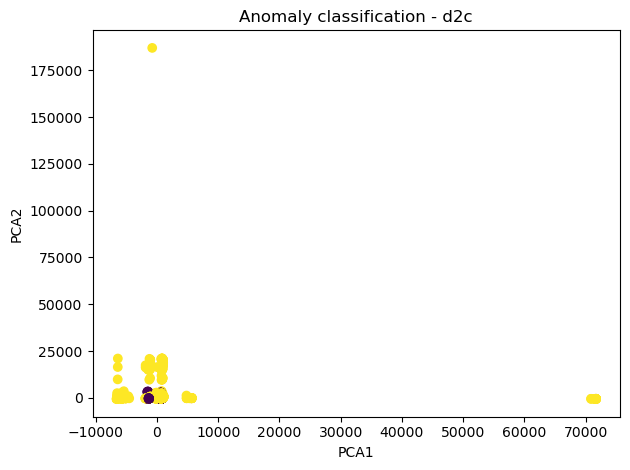

In [34]:
# Gráfico de datos y anomalías DATASET
plt.scatter(resultsF['pca1'],resultsF['pca2'],c=data_scaledF['anomaly'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Anomaly classification - d2c')
plt.tight_layout()

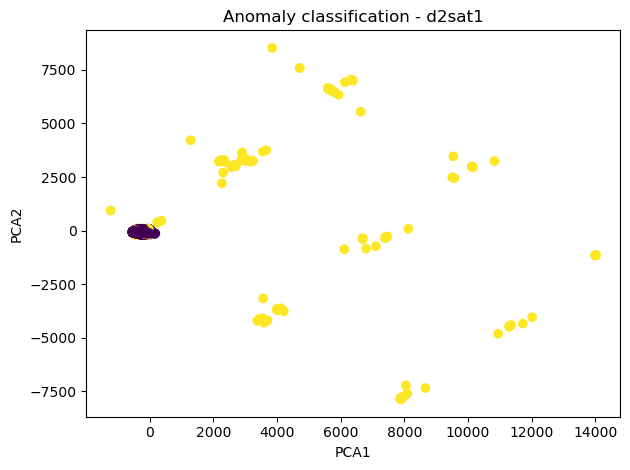

In [35]:
# Gráfico de datos y anomalías DATASET
plt.scatter(results1['pca1'],results1['pca2'],c=data_scaled1['anomaly'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Anomaly classification - d2sat1')
plt.tight_layout()

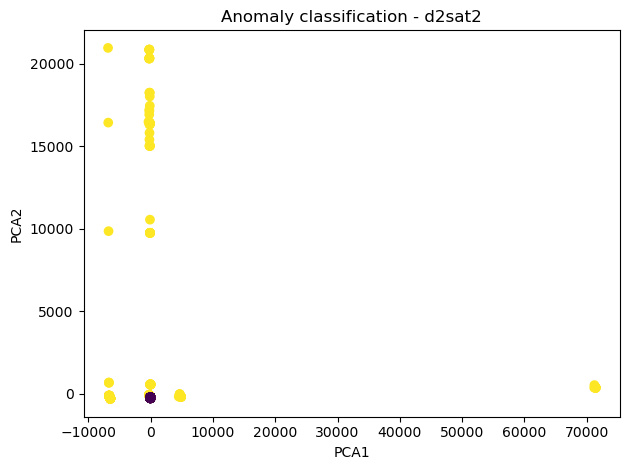

In [36]:
# Gráfico de datos y anomalías DATASET
plt.scatter(results2['pca1'],results2['pca2'],c=data_scaled2['anomaly'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Anomaly classification - d2sat2')
plt.tight_layout()

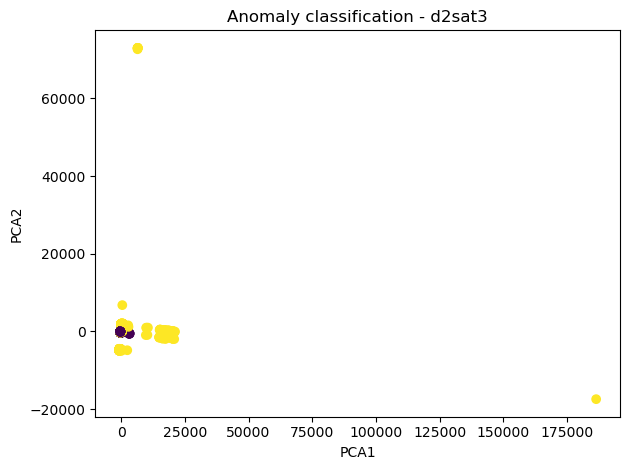

In [37]:
# Gráfico de datos y anomalías DATASET
plt.scatter(results3['pca1'],results3['pca2'],c=data_scaled3['anomaly'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Anomaly classification - d2sat3')
plt.tight_layout()

## Selección de características

### Estudio correlación

In [30]:
# Calculamos la correlación de los datos con la variable objetivo
correlation_matrixF = data_scaledF.corr()
corr_vs_anomalyF = correlation_matrixF['anomaly']

correlation_matrix1 = data_scaled1.corr()
corr_vs_anomaly1 = correlation_matrix1['anomaly']

correlation_matrix2 = data_scaled2.corr()
corr_vs_anomaly2 = correlation_matrix2['anomaly']

correlation_matrix3 = data_scaled3.corr()
corr_vs_anomaly3 = correlation_matrix3['anomaly']

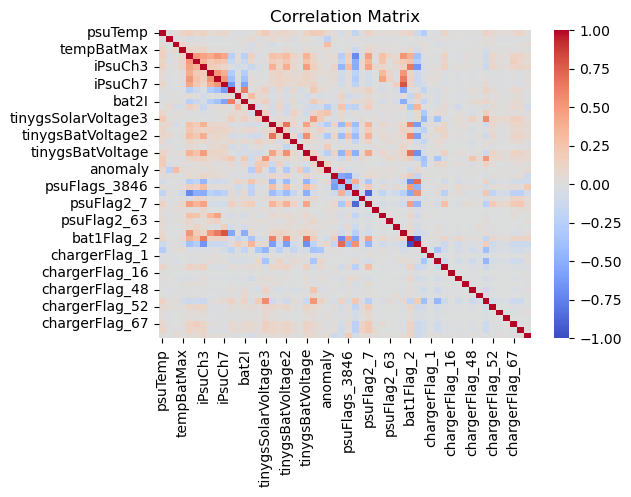

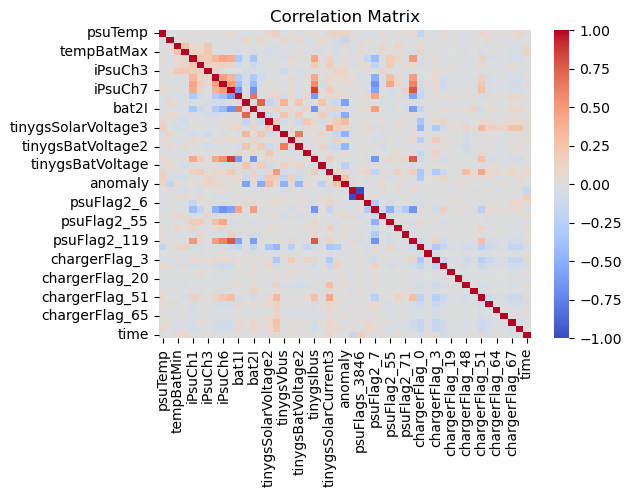

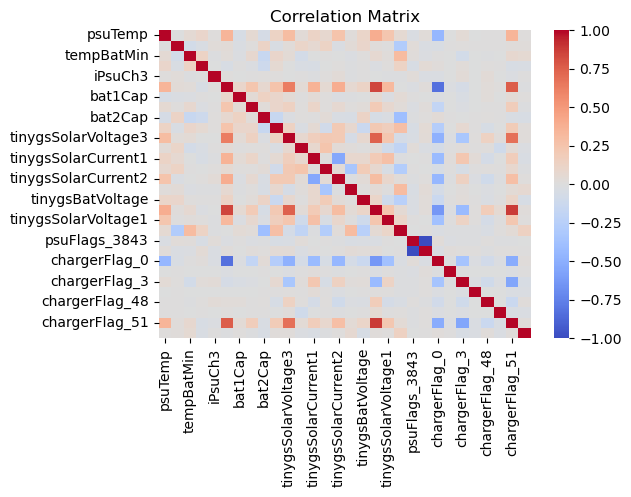

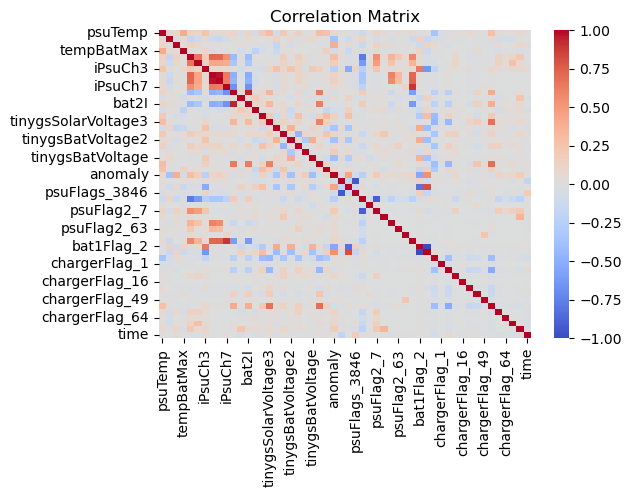

In [31]:
# Gráfico de correlaciones
plt.figure(figsize=(6, 4))  # Adjust the size to your needs
sns.heatmap(correlation_matrixF, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

plt.figure(figsize=(6, 4))  # Adjust the size to your needs
sns.heatmap(correlation_matrix1, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

plt.figure(figsize=(6, 4))  # Adjust the size to your needs
sns.heatmap(correlation_matrix2, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

plt.figure(figsize=(6, 4))  # Adjust the size to your needs
sns.heatmap(correlation_matrix3, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [32]:
# Observamos las correlaciones más significativas
print(corr_vs_anomalyF.sort_values(ascending=True))
print()
print(corr_vs_anomaly1.sort_values(ascending=True))
print()
print(corr_vs_anomaly2.sort_values(ascending=True))
print()
print(corr_vs_anomaly3.sort_values(ascending=True))

tinygsBatVoltage2     -0.304384
tinygsVbus            -0.281552
bat2Cap               -0.267516
tinygsBatVoltage      -0.243152
batCharge             -0.234083
bat1Flag_2            -0.092509
psuFlags_3846         -0.042447
psuFlags_3843         -0.024648
bat1Cap               -0.022706
psuFlag2_4            -0.020975
tinygsSolarVoltage3   -0.020214
psuFlag2_6            -0.016180
chargerFlag_67        -0.011203
chargerFlag_3         -0.011193
chargerFlag_19        -0.008761
chargerFlag_52        -0.007663
chargerFlag_16        -0.003699
psuFlag2_119          -0.002180
chargerFlag_0         -0.001706
iPsuCh3                0.000048
chargerFlag_1          0.000485
chargerFlag_48         0.000703
psuFlag2_55            0.001876
chargerFlag_4          0.006740
chargerFlag_49         0.007759
chargerFlag_68         0.009625
chargerFlag_51         0.009952
chargerFlag_64         0.010689
chargerFlag_20         0.011153
tinygsSolarCurrent3    0.012627
iPsuCh7                0.015188
psuFlag2

### Estudio información mutua

In [33]:
# Separamos la variable objetivo
XF = data_scaledF.drop(columns=['anomaly'])
YF = data_scaledF['anomaly']

X1 = data_scaled1.drop(columns=['anomaly'])
Y1 = data_scaled1['anomaly']

X2 = data_scaled2.drop(columns=['anomaly'])
Y2 = data_scaled2['anomaly']

X3 = data_scaled3.drop(columns=['anomaly'])
Y3 = data_scaled3['anomaly']

In [34]:
# Calculamos la información mutua, y la agrupamos en un dataframe
mi_scoresF = mutual_info_classif(XF, YF)
mi_scores1 = mutual_info_classif(X1, Y1)
mi_scores2 = mutual_info_classif(X2, Y2)
mi_scores3 = mutual_info_classif(X3, Y3)

data_mi_F = {'info_score': mi_scoresF}
data_mi_1 = {'info_score': mi_scores1}
data_mi_2 = {'info_score': mi_scores2}
data_mi_3 = {'info_score': mi_scores3}

info_mutuaF = pd.DataFrame(data=data_mi_F, index=XF.columns)
info_mutua1 = pd.DataFrame(data=data_mi_1, index=X1.columns)
info_mutua2 = pd.DataFrame(data=data_mi_2, index=X2.columns)
info_mutua3 = pd.DataFrame(data=data_mi_3, index=X3.columns)

In [35]:
# Filtramos los campos con información inferior a 0.05
variables_irrelevantesF = list(info_mutuaF[info_mutuaF['info_score']<0.005].index)
variables_irrelevantes1 = list(info_mutua1[info_mutua1['info_score']<0.005].index)
variables_irrelevantes2 = list(info_mutua2[info_mutua2['info_score']<0.005].index)
variables_irrelevantes3 = list(info_mutua3[info_mutua3['info_score']<0.005].index)

In [36]:
# Se descartan las variables irrelevantes de cada dataset
data_selectedF = data_scaledF.drop(columns=variables_irrelevantesF)
data_selected1 = data_scaled1.drop(columns=variables_irrelevantes1)
data_selected2 = data_scaled2.drop(columns=variables_irrelevantes2)
data_selected3 = data_scaled3.drop(columns=variables_irrelevantes3)

In [37]:
print(data_selectedF.shape)
print(data_selected1.shape)
print(data_selected2.shape)
print(data_selected3.shape)

(10063, 23)
(2915, 27)
(3680, 20)
(3468, 37)


## División train-test (Random)

In [38]:
# Separamos la variable objetivo del dataset
XF = data_selectedF.drop('anomaly', axis=1)
yF = data_selectedF['anomaly']

X1 = data_selected1.drop('anomaly', axis=1)
y1 = data_selected1['anomaly']

X2 = data_selected2.drop('anomaly', axis=1)
y2 = data_selected2['anomaly']

X3 = data_selected3.drop('anomaly', axis=1)
y3 = data_selected3['anomaly']

In [39]:
# Dividimos los datos: 80% train, 20% test
XF_train, XF_test, yF_train, yF_test = train_test_split(XF, yF, test_size=0.2, random_state=32)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=33)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=34)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=35)

In [40]:
print(yF_test.value_counts())
print(y1_test.value_counts())
print(y2_test.value_counts())
print(y3_test.value_counts())

anomaly
0.0    1756
1.0     257
Name: count, dtype: int64
anomaly
0.0    520
1.0     63
Name: count, dtype: int64
anomaly
0.0    641
1.0     95
Name: count, dtype: int64
anomaly
0.0    598
1.0     96
Name: count, dtype: int64


In [41]:
print(yF_train.value_counts())
print(y1_train.value_counts())
print(y2_train.value_counts())
print(y3_train.value_counts())

anomaly
0.0    7089
1.0     961
Name: count, dtype: int64
anomaly
0.0    2095
1.0     237
Name: count, dtype: int64
anomaly
0.0    2578
1.0     366
Name: count, dtype: int64
anomaly
0.0    2413
1.0     361
Name: count, dtype: int64


In [42]:
# Concatenamos los datos
datos_validacionF = XF_test
datos_validacionF['anomaly'] = yF_test

datos_validacion1 = X1_test
datos_validacion1['anomaly'] = y1_test

datos_validacion2 = X2_test
datos_validacion2['anomaly'] = y2_test

datos_validacion3 = X3_test
datos_validacion3['anomaly'] = y3_test

datos_entrenamientoF = XF_train
datos_entrenamientoF['anomaly'] = yF_train

datos_entrenamiento1 = X1_train
datos_entrenamiento1['anomaly'] = y1_train

datos_entrenamiento2 = X2_train
datos_entrenamiento2['anomaly'] = y2_train

datos_entrenamiento3 = X3_train
datos_entrenamiento3['anomaly'] = y3_train

In [45]:
# Movemos el tiempo a la primera posición
datos_validacionF = datos_validacionF[['time']+[col for col in datos_validacionF.columns if col != 'time']]
datos_validacion1 = datos_validacion1[['time']+[col for col in datos_validacion1.columns if col != 'time']]
datos_validacion2 = datos_validacion2[['time']+[col for col in datos_validacion2.columns if col != 'time']]
datos_validacion3 = datos_validacion3[['time']+[col for col in datos_validacion3.columns if col != 'time']]

datos_entrenamientoF = datos_entrenamientoF[['time']+[col for col in datos_entrenamientoF.columns if col != 'time']]
datos_entrenamiento1 = datos_entrenamiento1[['time']+[col for col in datos_entrenamiento1.columns if col != 'time']]
datos_entrenamiento2 = datos_entrenamiento2[['time']+[col for col in datos_entrenamiento2.columns if col != 'time']]
datos_entrenamiento3 = datos_entrenamiento3[['time']+[col for col in datos_entrenamiento3.columns if col != 'time']]

# Reordenamos los datos de forma temporal
datos_validacionF = datos_validacionF.sort_values(by='time')
datos_validacion1 = datos_validacion1.sort_values(by='time')
datos_validacion2 = datos_validacion2.sort_values(by='time')
datos_validacion3 = datos_validacion3.sort_values(by='time')

datos_entrenamientoF = datos_entrenamientoF.sort_values(by='time')
datos_entrenamiento1 = datos_entrenamiento1.sort_values(by='time')
datos_entrenamiento2 = datos_entrenamiento2.sort_values(by='time')
datos_entrenamiento3 = datos_entrenamiento3.sort_values(by='time')

# Exportamos el dataset de validación
datos_validacionF.to_excel("N_datos_validacion_rand_satF.xlsx")
datos_validacion1.to_excel("N_datos_validacion_rand_sat1.xlsx")
datos_validacion2.to_excel("N_datos_validacion_rand_sat2.xlsx")
datos_validacion3.to_excel("N_datos_validacion_rand_sat3.xlsx")

# Exportamos el dataset de entrenamiento
datos_entrenamientoF.to_excel("N_datos_entrenamiento_rand_satF.xlsx")
datos_entrenamiento1.to_excel("N_datos_entrenamiento_rand_sat1.xlsx")
datos_entrenamiento2.to_excel("N_datos_entrenamiento_rand_sat2.xlsx")
datos_entrenamiento3.to_excel("N_datos_entrenamiento_rand_sat3.xlsx")

## División train-test (Serie)

In [46]:
# Separamos la variable objetivo del dataset
Xs1 = data_selected1
Xs2 = data_selected2
Xs3 = data_selected3

In [47]:
# Movemos el tiempo a la primera posición
Xs1 = Xs1[['time']+[col for col in Xs1.columns if col != 'time']]
Xs2 = Xs2[['time']+[col for col in Xs2.columns if col != 'time']]
Xs3 = Xs3[['time']+[col for col in Xs3.columns if col != 'time']]

# Reordenamos los datos de forma temporal
Xs1 = Xs1.sort_values(by='time')
Xs2 = Xs2.sort_values(by='time')
Xs3 = Xs3.sort_values(by='time')

In [48]:
Xs1_norm = Xs1[Xs1.anomaly == 0]
Xs1_anom = Xs1[Xs1.anomaly == 1]

Xs2_norm = Xs2[Xs2.anomaly == 0]
Xs2_anom = Xs2[Xs2.anomaly == 1]

Xs3_norm = Xs3[Xs3.anomaly == 0]
Xs3_anom = Xs3[Xs3.anomaly == 1]

In [49]:
Xs3_anom.shape

(457, 37)

In [50]:
train_size1 = int(2*len(Xs1)/3)
train_size2 = int(2*len(Xs2)/3)
train_size3 = int(2*len(Xs3)/3)

In [51]:
len(Xs1)

2915

In [71]:
# Split into training and test sets -> ajuste de indices para separar en 0.33 train/0.33 validacion/0.33 test
train_data_1 = Xs1_norm.iloc[:train_size1-1]
test_data_1 = Xs1_norm.iloc[train_size1+1:]
test_data_1 = pd.concat([test_data_1, Xs1_anom], axis=0)

train_data_2 = Xs2_norm.iloc[:train_size2-1]
test_data_2 = Xs2_norm.iloc[train_size2+1:]
test_data_2 = pd.concat([test_data_2, Xs2_anom], axis=0)

train_data_3 = Xs3_norm.iloc[:train_size3]
test_data_3 = Xs3_norm.iloc[train_size3:]
test_data_3 = pd.concat([test_data_3, Xs3_anom], axis=0)

In [76]:
print("Data1:")
print(train_data_1.shape)
print(test_data_1.shape[0]*2)
print()
print("Data2:")
print(train_data_2.shape)
print(test_data_2.shape[0]*2)
print()
print("Data3:")
print(train_data_3.shape)
print(test_data_3.shape[0]*2)

Data1:
(1942, 27)
1942

Data2:
(2452, 20)
2452

Data3:
(2312, 37)
2312


In [77]:
# Reordenamos los datos de forma temporal
train_data_1 = train_data_1.sort_values(by='time')
train_data_2 = train_data_2.sort_values(by='time')
train_data_3 = train_data_3.sort_values(by='time')

test_data_1 = test_data_1.sort_values(by='time')
test_data_2 = test_data_2.sort_values(by='time')
test_data_3 = test_data_3.sort_values(by='time')

In [79]:
# Exportamos los datos de entrenamiento
train_data_1.to_excel("N_datos_entrenamiento_serie_sat1.xlsx")
train_data_2.to_excel("N_datos_entrenamiento_serie_sat2.xlsx")
train_data_3.to_excel("N_datos_entrenamiento_serie_sat3.xlsx")

# Exportamos el dataset de validación
test_data_1.to_excel("N_datos_validacion_serie_sat1.xlsx")
test_data_2.to_excel("N_datos_validacion_serie_sat2.xlsx")
test_data_3.to_excel("N_datos_validacion_serie_sat3.xlsx")

## Upsampling (NO USADO)

In [107]:
# Analizamos el dataset para ver el equilibrio de variables
distribution1 = datos_entrenamiento1['anomaly'].value_counts()
print(distribution1)

distribution2 = datos_entrenamiento2['anomaly'].value_counts()
print(distribution2)

distribution3 = datos_entrenamiento3['anomaly'].value_counts()
print(distribution3)

anomaly
0    1987
1     104
Name: count, dtype: int64
anomaly
0    2448
1     127
Name: count, dtype: int64
anomaly
0    2283
1     125
Name: count, dtype: int64


In [108]:
# Dividimos el dataset en las 2 clases
df_majority1 = datos_entrenamiento1[datos_entrenamiento1['anomaly'] == 0]
df_minority1 = datos_entrenamiento1[datos_entrenamiento1['anomaly'] == 1]

df_majority2 = datos_entrenamiento2[datos_entrenamiento2['anomaly'] == 0]
df_minority2 = datos_entrenamiento2[datos_entrenamiento2['anomaly'] == 1]

df_majority3 = datos_entrenamiento3[datos_entrenamiento3['anomaly'] == 0]
df_minority3 = datos_entrenamiento3[datos_entrenamiento3['anomaly'] == 1]

In [109]:
# Realizamos el upsampling de la clase minoritaria
df_minority_upsampled1 = resample(df_minority1,
                                   replace=True,
                                   n_samples=len(df_majority1),
                                   random_state=33)

df_minority_upsampled2 = resample(df_minority2,
                                   replace=True,
                                   n_samples=len(df_majority2),
                                   random_state=34)

df_minority_upsampled3 = resample(df_minority3,
                                   replace=True,
                                   n_samples=len(df_majority3),
                                   random_state=35)

data_upsampled1 = pd.concat([df_minority_upsampled1, df_majority1])
data_upsampled2 = pd.concat([df_minority_upsampled2, df_majority2])
data_upsampled3 = pd.concat([df_minority_upsampled3, df_majority3])

In [110]:
print(data_upsampled1['anomaly'].value_counts())
print(data_upsampled2['anomaly'].value_counts())
print(data_upsampled3['anomaly'].value_counts())

anomaly
1    1987
0    1987
Name: count, dtype: int64
anomaly
1    2448
0    2448
Name: count, dtype: int64
anomaly
1    2283
0    2283
Name: count, dtype: int64


In [111]:
# Movemos el tiempo a la primera posición
data_upsampled1 = data_upsampled1[['time']+[col for col in data_upsampled1.columns if col != 'time']]
data_upsampled2 = data_upsampled2[['time']+[col for col in data_upsampled2.columns if col != 'time']]
data_upsampled3 = data_upsampled3[['time']+[col for col in data_upsampled3.columns if col != 'time']]

# Reordenamos los datos de forma temporal
data_upsampled1 = data_upsampled1.sort_values(by='time')
data_upsampled2 = data_upsampled2.sort_values(by='time')
data_upsampled3 = data_upsampled3.sort_values(by='time')

# Exportamos los datos de entrenamiento
data_upsampled1.to_excel("datos_entrenamiento_sat1.xlsx")
data_upsampled2.to_excel("datos_entrenamiento_sat2.xlsx")
data_upsampled3.to_excel("datos_entrenamiento_sat3.xlsx")